This notebook is setting up GLM model.
The steps include:
1. Load the data and clean with same pipeline as other models, and remove highly correlated features with spearman correlation $\rho > 0.7$.
2. Use LASSO regression with gaussian and log10(outbreak count) to select important features. 
3. Further reduce the features by bidirectional stepwise regression with AIC as the selection criteria and negative binomial regression with outbreak count as the response variable.
4. Evaluate the model by computing RMSE, MAE, AUC, and $R^2$ on the test set; check residual plots
5. Obtain predicted vs actual outbreak counts scatter plot on both training and test sets, and obtain forest plot of the coefficients with 95% confidence intervals.

In [21]:
# load lib
library(tidyverse)
library(glmnet)
library(glmmTMB)
library(caret)
library(DHARMa)
library(readr)
library(dplyr)
library(janitor)
library(buildmer)
library(glmmTMB)
# set path
library(here)
setwd(here::here())

We fix seed to 100. We clean the dataset by
- dropping redundant yes/no columns
- removing counties without students and SVI data
- adding density column
- removing margin error, raw counts, estimated percentage quantiles and SVI theme scores
- Remove columns contain any missing values
- remove redundant columns from SVI and ACS data(e.g., pct_poverty from ACS is overlapped with ep_POV150 from SVI, we keep the ACS version)

In [22]:
drop_redundant_yn_features <- function(df) {
  # Get all column names
  cols <- names(df)
  
  # Find Yes/No pairs by stripping the suffix
  yes_cols <- cols[grepl("_yes", cols)]
  no_cols  <- cols[grepl("_no",  cols)]
  
  # Get base names for each
  yes_bases <- sub("_diff$", "", sub("_yes", "", yes_cols))
  no_bases  <- sub("_diff$", "", sub("_no",  "", no_cols))
  
  # Find bases that have BOTH a Yes and No column
  paired_bases <- intersect(yes_bases, no_bases)
  
  cols_to_drop <- c()
  
  for (base in paired_bases) {
    yes_col <- yes_cols[yes_bases == base]
    no_col  <- no_cols[no_bases == base]
    
    # Count NAs in each
    yes_nas <- sum(is.na(df[[yes_col]]))
    no_nas  <- sum(is.na(df[[no_col]]))
    
    # Drop whichever has more NAs 
    # If tied drop "No" (keep "Yes")
    if (no_nas >= yes_nas) {
      cols_to_drop <- c(cols_to_drop, no_col)
    } else {
      cols_to_drop <- c(cols_to_drop, yes_col)
    }
  }
  
  cat("Dropping", length(cols_to_drop), "redundant columns:\n")
  #cat(paste(" ", cols_to_drop), sep = "\n")
  
  df[, !names(df) %in% cols_to_drop]
}

set.seed(100)

df <- read_csv("data/merged_with_svi.csv", show_col_types = FALSE) |> clean_names() 

df <- df %>% filter(!county %in% c("Mcculloch", "Mclennan", "Mcmullen", "Dewitt", "Loving"))
df_raw <- df
df$density <- df$population*1.0/df$area_sqmi
df <- df %>% dplyr::select(-c("county", "area_sqmi"), -starts_with("m_"), -starts_with("mp_"), -starts_with("e_"), -starts_with("epl_"), -starts_with("spl_"), -starts_with("rpl_"), -starts_with("f_"))
df <- df[,colSums(is.na(df)) == 0]
df <- df %>% dplyr::select(-c("ep_minrty", "ep_hisp", "ep_afam", "ep_pov150", "ep_uninsur"))

df <- drop_redundant_yn_features(df)

index <- createDataPartition(df$outbreak, p = 0.75, list = FALSE)
train <- df[index,]
test <- df[-index,]
PHR <- train$phr
offset <- log(train$enrollment)
enrollment <- train$enrollment
outbreak <- train$outbreak
train <- train %>% dplyr::select(-c("phr", "enrollment", "population", "outbreak"))

Dropping 82 redundant columns:


We start with the full list of predictors, and to reduce multicollinearity, we greedily remove predictors that are highly correlated with other predictors. We use a threshold of 0.7 for the absolute value of the Spearman correlation coefficient to determine if two predictors are highly correlated. If two predictors are highly correlated, we remove the predictor that has less correlation with the outcome variable.

In [23]:
X <- as.matrix(train)
y <- outbreak

# Start with full list of candidates
candidates <- colnames(X)

i <- 1
while (i < length(candidates)) {
  j <- i + 1
  while (j <= length(candidates)) {
    rho <- cor(X[, candidates[i]], X[, candidates[j]], 
               method = "spearman", use = "complete.obs")
    if (abs(rho) >= 0.7) {
      # Drop whichever has weaker correlation with outcome
      rho_i <- abs(cor(X[, candidates[i]], y, method = "spearman", use = "complete.obs"))
      rho_j <- abs(cor(X[, candidates[j]], y, method = "spearman", use = "complete.obs"))
      if (rho_i >= rho_j) {
        candidates <- candidates[-j]  
      } else {
        candidates <- candidates[-i]  
        j <- i + 1
      }
    } else {
      j <- j + 1
    }
  }
  i <- i + 1
}

X <- X[, candidates]
X

cve,pct_black,pct_poverty,pct_uninsured,pct_college,pct_foreign_born,bmi_3_categories_recommended_range,hlth_affected_activ_5_days_5_or_more_days,mammogram_past_2_yrs_40_ia_yes,pain_med_not_rx_no,⋯,ep_crowd,ep_noveh,ep_groupq,ep_noint,ep_asian,ep_aian,ep_nhpi,ep_twomore,ep_otherrace,density
2.54,18.6,13.5,18.5,15.4,1.1,25.4,19.8,69.8,99.2,⋯,5.1,6.5,21.7,17.8,0.7,0.7,0.1,4.7,0.2,56.749551
1.91,1.6,14.2,22.4,17.7,1.2,21.7,16.3,62.4,94.1,⋯,5.5,1.6,0.7,9.2,0.5,0.0,0.0,0.8,0.1,13.208987
2.06,1.3,10.7,12.8,28.8,1.5,27.0,21.6,77.8,94.5,⋯,5.1,5.1,1.4,10.6,1.7,0.5,0.0,2.2,0.0,102.920403
2.70,1.5,4.5,13.9,25.4,0.8,30.0,20.6,63.1,98.5,⋯,1.7,2.5,0.8,16.8,0.2,0.4,0.0,3.1,0.0,9.937021
1.08,1.2,13.6,19.5,15.7,1.2,28.7,22.1,65.5,96.1,⋯,8.1,5.5,0.9,15.3,0.5,0.0,0.0,1.5,0.1,42.896443
3.55,7.9,10.6,16.7,25.1,1.1,32.5,14.8,74.6,96.5,⋯,5.7,3.5,1.0,19.4,0.5,0.1,0.0,2.1,0.4,50.979487
3.78,1.2,8.5,13.3,27.2,1.5,28.7,22.1,65.5,96.1,⋯,3.9,1.5,2.2,12.1,0.5,0.5,0.0,2.9,0.6,28.973700
2.09,5.8,7.0,21.8,25.0,1.4,34.1,19.1,70.3,96.5,⋯,4.1,2.9,2.5,15.6,0.7,0.1,0.0,3.2,0.3,131.545103
0.88,1.2,16.0,20.6,25.3,1.6,30.0,20.6,63.1,98.5,⋯,3.6,3.1,2.3,18.1,0.0,0.2,1.1,5.8,0.0,4.068104
1.48,7.3,11.8,18.8,14.0,0.8,27.0,21.6,77.8,94.5,⋯,3.7,5.0,23.7,24.4,0.6,0.3,0.0,3.1,0.2,34.223660


To decide the lambda parameter for the LASSO regression, we fix the seed and use 10-fold cross-validation to find the optimal lambda that minimizes the mean squared error with gaussian and log10 of outcome(to ensure convergence). We then fit the LASSO model using this optimal lambda and extract the coefficients of the predictors. We keep the predictors with coefficients larger than 1e-5 in absolute value.

In [24]:
set.seed(100)
cv.lasso <- cv.glmnet(X, log10(y + 1), family = "gaussian", alpha = 1)
best.lambda <- cv.lasso$lambda.min
print(best.lambda)
lasso_coef <- coef(cv.lasso, s = "lambda.min")
lasso_vars <- rownames(lasso_coef)[
  abs(lasso_coef[, 1]) >= 1e-5 & !grepl("Intercept", rownames(lasso_coef))
]
lasso_vars

[1] 0.03019285


[1] "cve"                                                
[2] "mammogram_past_2_yrs_40_ia_yes"                     
[3] "skin_cancer_no"                                     
[4] "heavy_drinking_females_no_pct_diff"                 
[5] "last_dentist_visit_within_the_past_2_years_pct_diff"
[6] "poor_mental_health_14_days_14_or_more_days_pct_diff"
[7] "ep_nohsdp"                                          
[8] "ep_age65"

We fit the variables to the negative binomial model with LASSO selected predictors, and offset as log(enrollment). We notice some predictors are not significant, so we move onto bidirectional stepwise selection to further reduce the number of predictors.

In [25]:
df <- data.frame(y = y, X[,lasso_vars , drop = FALSE], offset = offset)

base <- glmmTMB(
  y ~ cve + mammogram_past_2_yrs_40_ia_yes + poor_mental_health_14_days_14_or_more_days_pct_diff + ep_nohsdp + skin_cancer_no+ heavy_drinking_females_no_pct_diff + last_dentist_visit_within_the_past_2_years_pct_diff + ep_age65 + offset(offset),  
  data = df,
  family = nbinom2
)
summary(base)

 Family: nbinom2  ( log )
Formula:          
y ~ cve + mammogram_past_2_yrs_40_ia_yes + poor_mental_health_14_days_14_or_more_days_pct_diff +  
    ep_nohsdp + skin_cancer_no + heavy_drinking_females_no_pct_diff +  
    last_dentist_visit_within_the_past_2_years_pct_diff + ep_age65 +  
    offset(offset)
Data: df

      AIC       BIC    logLik -2*log(L)  df.resid 
    259.9     292.2    -120.0     239.9       177 


Dispersion parameter for nbinom2 family (): 0.23 

Conditional model:
                                                      Estimate Std. Error
(Intercept)                                         -36.916633  29.130288
cve                                                   0.515191   0.184640
mammogram_past_2_yrs_40_ia_yes                       -0.220982   0.076781
poor_mental_health_14_days_14_or_more_days_pct_diff  -0.020918   0.009797
ep_nohsdp                                             0.076552   0.040459
skin_cancer_no                                        0.418912   0

We perform bidirectional stepwise selection using AIC as the criterion for model selection, and obtain a final model with 4 predictors. We then fit the final model and obtain estimates and p-values for the predictors. We also check for multicollinearity using the variance inflation factor (VIF) and find that all predictors have VIF less than 5 so there is no multicollinearity issue.

In [26]:
selected_vars <- c("cve", "mammogram_past_2_yrs_40_ia_yes","poor_mental_health_14_days_14_or_more_days_pct_diff","ep_nohsdp")  

df <- data.frame(y = y, X[, selected_vars, drop = FALSE], offset = offset)

full_formula <- y ~ cve + mammogram_past_2_yrs_40_ia_yes + skin_cancer_no +
  heavy_drinking_females_no_pct_diff +
  last_dentist_visit_within_the_past_2_years_pct_diff +
  poor_mental_health_14_days_14_or_more_days_pct_diff +
  ep_nohsdp + ep_age65


set.seed(100)

m <- buildglmmTMB(
  full_formula,
  data = df,
  family = nbinom2,
  buildmerControl = buildmerControl(
    direction = c("order", "backward", "forward"),
    crit = "AIC",
    calc.summary = TRUE,
    include = ~ offset(offset)
  )
)
summary(m@model)
m@p$results
formula(m)

rhs <- paste(selected_vars, collapse = " + ")

f_fixed <- as.formula(paste("y ~", rhs, "+ offset(offset)"))

m_fixed <- glmmTMB(f_fixed, data = df, family = nbinom2)
summary(m_fixed)
performance::check_collinearity(m_fixed)

Determining predictor order

Fitting via glmmTMB, with ML: y ~ 1 + offset(offset)

Currently evaluating AIC for: cve, mammogram_past_2_yrs_40_ia_yes,
    skin_cancer_no, heavy_drinking_females_no_pct_diff,
    last_dentist_visit_within_the_past_2_years_pct_diff,
    poor_mental_health_14_days_14_or_more_days_pct_diff, ep_nohsdp,
    ep_age65

Fitting via glmmTMB, with ML: y ~ offset(offset) + 1 + cve

Fitting via glmmTMB, with ML: y ~ offset(offset) + 1 +
    mammogram_past_2_yrs_40_ia_yes

Fitting via glmmTMB, with ML: y ~ offset(offset) + 1 + skin_cancer_no



Error in eval(predvars, data, env) : object 'skin_cancer_no' not found


Fitting via glmmTMB, with ML: y ~ offset(offset) + 1 +
    heavy_drinking_females_no_pct_diff



Error in eval(predvars, data, env) : 
  object 'heavy_drinking_females_no_pct_diff' not found


Fitting via glmmTMB, with ML: y ~ offset(offset) + 1 +
    last_dentist_visit_within_the_past_2_years_pct_diff



...

 Family: nbinom2  ( log )
Formula:          
y ~ offset(offset) + 1 + mammogram_past_2_yrs_40_ia_yes + cve +  
    ep_nohsdp + poor_mental_health_14_days_14_or_more_days_pct_diff
Data: df

      AIC       BIC    logLik -2*log(L)  df.resid 
    276.9     296.3    -132.4     264.9       181 


Dispersion parameter for nbinom2 family (): 0.168 

Conditional model:
                                                     Estimate Std. Error
(Intercept)                                          0.416646   3.747561
mammogram_past_2_yrs_40_ia_yes                      -0.187891   0.054252
cve                                                  0.504820   0.167959
ep_nohsdp                                            0.094340   0.040824
poor_mental_health_14_days_14_or_more_days_pct_diff -0.018821   0.009013
                                                    z value Pr(>|z|)    
(Intercept)                                           0.111 0.911475    
mammogram_past_2_yrs_40_ia_yes                      

,index,grouping,term,code,block,ok,score,Iteration,AIC
,<lgl>,<lgl>,<chr>,<chr>,<chr>,<lgl>,<dbl>,<dbl>,<dbl>
1,NA,NA,offset(offset),offset(offset),NA,TRUE,NA,1,NA
2,NA,NA,1,1,NA,TRUE,NA,1,NA
3,NA,NA,mammogram_past_2_yrs_40_ia_yes,mammogram_past_2_yrs_40_ia_yes,NA NA mammogram_past_2_yrs_40_ia_yes,TRUE,-32.842844,1,-32.842844
21,NA,NA,cve,cve,NA NA cve,TRUE,-16.080225,1,-16.080225
8,NA,NA,ep_nohsdp,ep_nohsdp,NA NA ep_nohsdp,TRUE,-3.259022,1,-3.259022
7,NA,NA,poor_mental_health_14_days_14_or_more_days_pct_diff,poor_mental_health_14_days_14_or_more_days_pct_diff,NA NA poor_mental_health_14_days_14_or_more_days_pct_diff,TRUE,-3.231406,1,-3.231406


y ~ offset(offset) + 1 + mammogram_past_2_yrs_40_ia_yes + cve + 
    ep_nohsdp + poor_mental_health_14_days_14_or_more_days_pct_diff
<environment: 0x14502a900>

 Family: nbinom2  ( log )
Formula:          
y ~ cve + mammogram_past_2_yrs_40_ia_yes + poor_mental_health_14_days_14_or_more_days_pct_diff +  
    ep_nohsdp + offset(offset)
Data: df

      AIC       BIC    logLik -2*log(L)  df.resid 
    257.4     276.8    -122.7     245.4       181 


Dispersion parameter for nbinom2 family (): 0.202 

Conditional model:
                                                     Estimate Std. Error
(Intercept)                                          0.695674   3.541810
cve                                                  0.496818   0.156535
mammogram_past_2_yrs_40_ia_yes                      -0.191729   0.051303
poor_mental_health_14_days_14_or_more_days_pct_diff -0.018984   0.008522
ep_nohsdp                                            0.094014   0.037870
                                                    z value Pr(>|z|)    
(Intercept)                                           0.196 0.844283    
cve                                                   3.

Term,VIF,VIF_CI_low,VIF_CI_high,SE_factor,Tolerance,Tolerance_CI_low,Tolerance_CI_high
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
cve,1.057943,1.004152,1.808645,1.028563,0.9452309,0.5529001,0.9958654
mammogram_past_2_yrs_40_ia_yes,1.529084,1.310665,1.901068,1.236562,0.6539861,0.5260202,0.7629713
poor_mental_health_14_days_14_or_more_days_pct_diff,1.291462,1.138597,1.612929,1.136425,0.7743161,0.6199903,0.8782737
ep_nohsdp,1.338615,1.171901,1.667013,1.156985,0.7470409,0.5998755,0.8533146


Checking the residuals for the final, we notice a systematic deviation from the expected distribution, indicating that the model may not be at regression. 

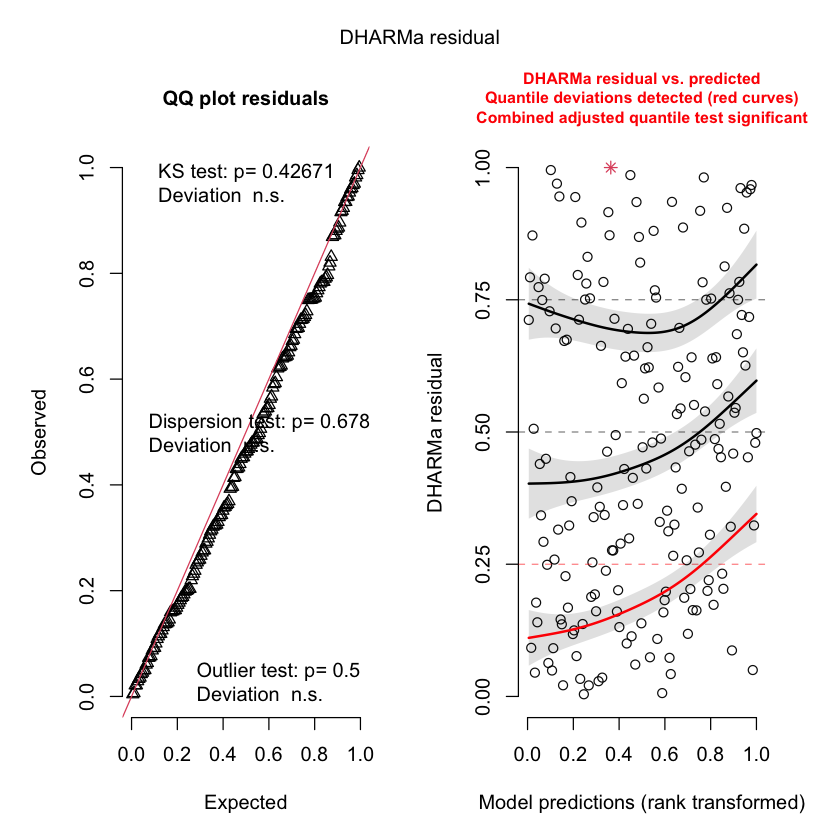


	DHARMa nonparametric dispersion test via sd of residuals fitted vs.
	simulated

data:  simulationOutput
dispersion = 0.17244, p-value = 0.678
alternative hypothesis: two.sided


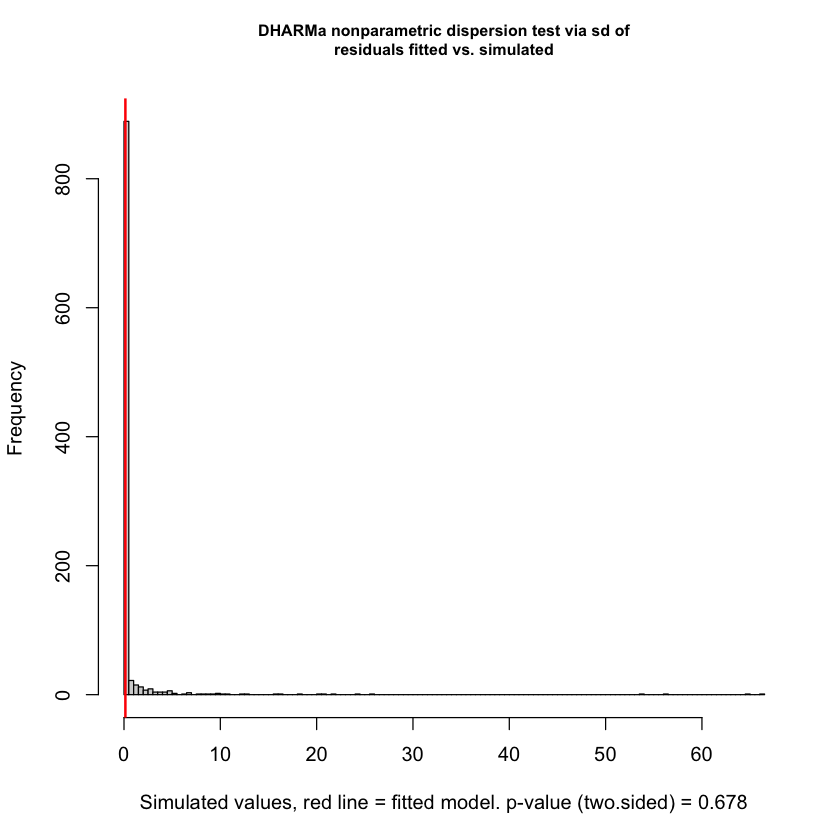


	DHARMa zero-inflation test via comparison to expected zeros with
	simulation under H0 = fitted model

data:  simulationOutput
ratioObsSim = 1.0069, p-value = 0.908
alternative hypothesis: two.sided


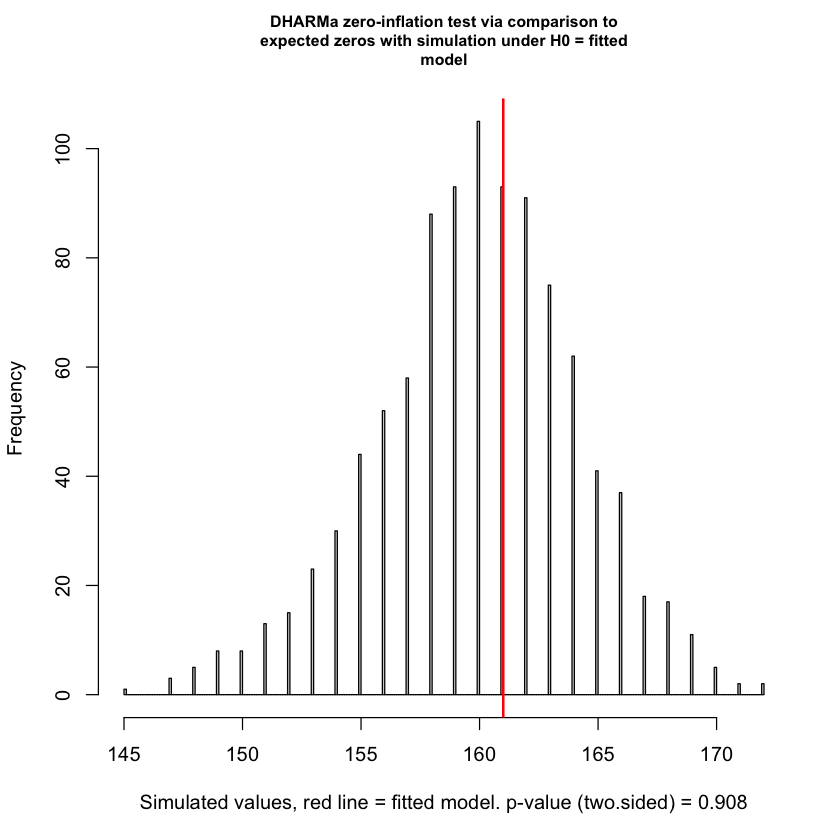


	DHARMa bootstrapped outlier test

data:  sim
outliers at both margin(s) = 1, observations = 187, p-value = 0.44
alternative hypothesis: two.sided
 percent confidence interval:
 0.000000000 0.005347594
sample estimates:
outlier frequency (expected: 0.00122994652406417 ) 
                                       0.005347594 


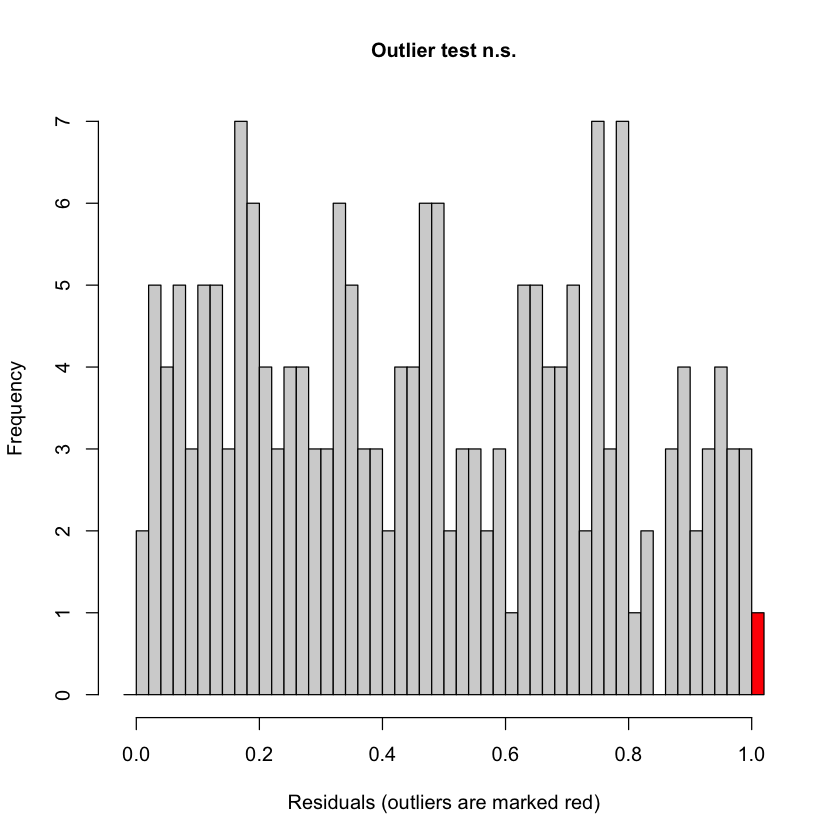

In [27]:
library(DHARMa)
set.seed(100)
sim <- simulateResiduals(m_fixed, n = 1000)
plot(sim)               
testDispersion(sim)   
testZeroInflation(sim)  
testOutliers(sim)


We then compute RMSE, MAE, McFadden's pseudo R-squared, and AUC to evaluate the model performance on both training and testing datasets. We notice the GLM is decently well in classifying the outbreak counties, but not as well in predicting the number of outbreak cases.

In [28]:
test$y      <- test$outbreak
test$offset <- log(test$enrollment)

pred_tr   <- predict(m_fixed, newdata = df,   type = "response")
pred_test <- predict(m_fixed, newdata = test, type = "response")

metrics_vec <- function(obs, pred, model, label) {
  theta <- sigma(model)
  data.frame(
    set      = label,
    n        = length(obs),
    rmse     = sqrt(mean((obs - pred)^2)),
    mae      = mean(abs(obs - pred)),
    spearman = cor(pred, obs, method = "spearman"),
    auc      = as.numeric(pROC::auc(pROC::roc(as.integer(obs > 3), pred, quiet = TRUE))),
    mean_ll  = mean(dnbinom(obs, size = theta, mu = pred, log = TRUE))
  )
}

perf <- rbind(
  metrics_vec(df$y,   pred_tr,   m_fixed, "train (in-sample)"),
  metrics_vec(test$y, pred_test, m_fixed, "test (out-of-sample)")
)
print(perf, row.names = FALSE, digits = 4)

n0_tr    <- glmmTMB(y ~ 1 + offset(offset), data = df, family = nbinom2)
pred0_te <- predict(n0_tr, newdata = test, type = "response")

ll_sum <- function(obs, pred, theta) sum(dnbinom(obs, size = theta, mu = pred, log = TRUE))

mcfadden_train <- 1 - as.numeric(logLik(m_fixed)) / as.numeric(logLik(n0_tr))
pseudo_R2  <- 1 - ll_sum(test$y, pred_test, sigma(m_fixed)) /
                      ll_sum(test$y, pred0_te,  sigma(n0_tr))

cat(sprintf("McFadden (train, in-sample)   : %.4f\n", mcfadden_train))
cat(sprintf("Pseudo-R2 (test, out-of-sample): %.4f\n", pseudo_R2))

                  set   n    rmse    mae spearman    auc mean_ll
    train (in-sample) 187 280.344 21.824   0.4308 0.8944 -0.6561
 test (out-of-sample)  62   8.273  2.015   0.4123 0.8526 -1.1070
McFadden (train, in-sample)   : 0.2054
Pseudo-R2 (test, out-of-sample): -0.1498


Additionally, we plot the predicted vs observed values for both training and testing datasets to visualize the model performance. 

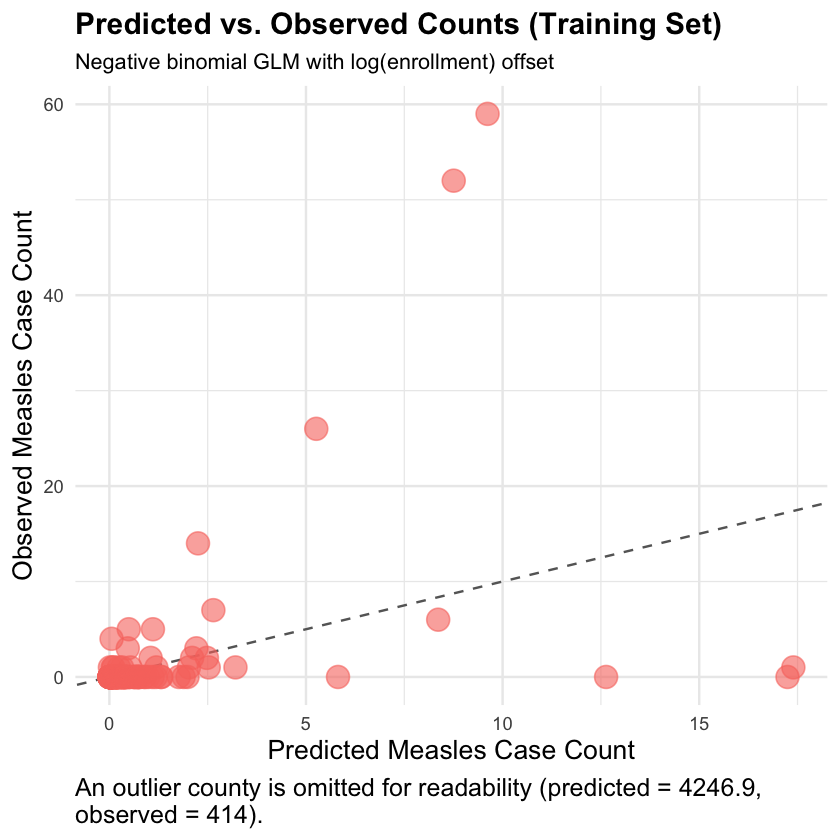

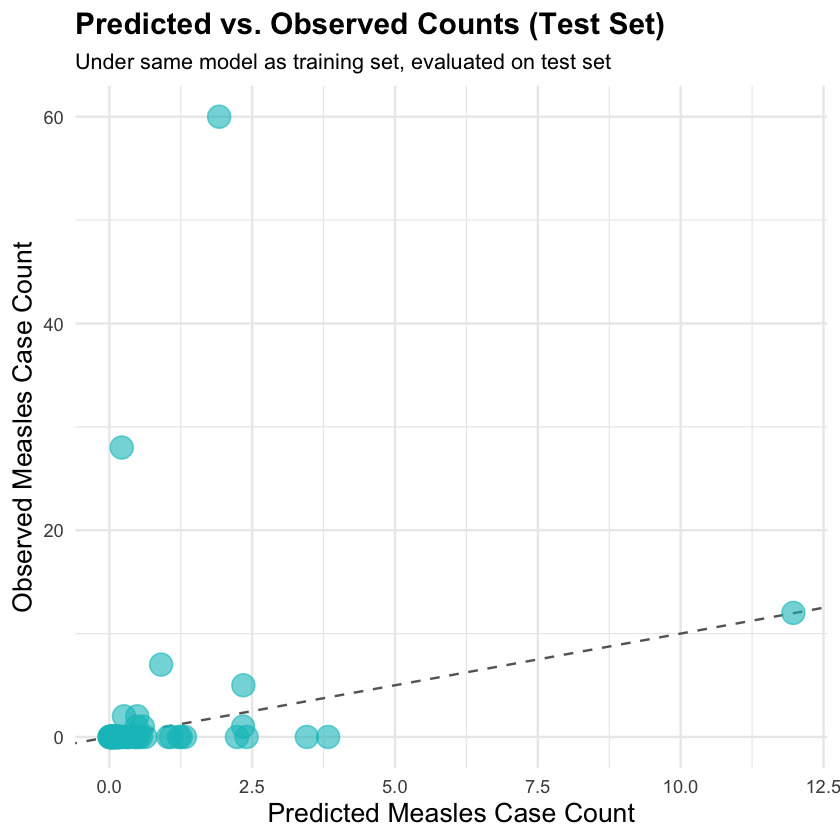

In [29]:
train_df <- data.frame(pred = pred_tr,   obs = df$y)
test_df  <- data.frame(pred = pred_test, obs = test$y)
outlier_thresh <- 100
train_outliers <- train_df %>% filter(obs > outlier_thresh | pred > outlier_thresh)
train_main     <- train_df %>% filter(obs <= outlier_thresh & pred <= outlier_thresh)

poster_theme <- theme_minimal(base_size = 15) +
  theme(
    plot.title    = element_text(size = 18, face = "bold"),
    plot.subtitle = element_text(size = 13),
    axis.title    = element_text(size = 16),
    axis.text     = element_text(size = 11),
    plot.caption  = element_text(size = 15, hjust = 0)
  )

p_train <- ggplot(train_main, aes(pred, obs)) +
  geom_abline(slope = 1, intercept = 0, linetype = "dashed", color = "grey40") +
  geom_count(alpha = 0.6, color = "#F8766D") +
  scale_size_area(max_size = 6, guide = "none") +
  labs(
    x = "Predicted Measles Case Count",
    y = "Observed Measles Case Count",
    title = "Predicted vs. Observed Counts (Training Set)",
    subtitle = "Negative binomial GLM with log(enrollment) offset",
    caption = str_wrap(paste0(
      "An outlier county is omitted for readability (predicted = 4246.9, observed = 414)."
    ), 65)
  ) +
  poster_theme

p_test <- ggplot(test_df, aes(pred, obs)) +
  geom_abline(slope = 1, intercept = 0, linetype = "dashed", color = "grey40") +
  geom_count(alpha = 0.6, color = "#00BFC4") +
  scale_size_area(max_size = 6, guide = "none") +
  labs(
    x = "Predicted Measles Case Count",
    y = "Observed Measles Case Count",
    title = "Predicted vs. Observed Counts (Test Set)",
    subtitle = "Under same model as training set, evaluated on test set",
  ) +
  poster_theme
p_train
p_test

We look into AUC to evaluate the model's ability to classify outbreak counties. We calculate the optimal threshold using Youden's J statistic, which maximizes the sum of sensitivity and specificity. Based on the optimal threshold, we create confusion matrices for both training and testing datasets to assess the model's classification performance. 

In [34]:
thr <- coords(roc_train, "best", best.method = "youden",
              ret = "threshold")$threshold
thr
table(predicted = as.integer(pred_train > thr), actual = as.integer(df$y   > 3))
table(predicted = as.integer(pred_test  > thr), actual = as.integer(test$y > 3))

[1] 1.103365

         actual
predicted   0   1
        0 160   2
        1  17   8

         actual
predicted  0  1
        0 49  2
        1  8  3

In [ ]:
Receiver operating characteristic (ROC) curve plots the true positive rate against the false positive rate at various threshold settings. Specifically, we define positive class for observations as counties with more than 4 measles cases as \ref{sec:param_tuning_outbreak}, and use Youden's Index to identify the optimal threshold $\alpha$ that optimizes the precision and recall for classifying predicted outcomes, where counties predicted to have more than $\alpha$ measles cases are classified as having an outbreak. 

The area under the ROC curve (AUC) provides a single measure of overall model performance, with values closer to 1 indicating better classification ability. By AUC score, we notice that the model correctly classifies around 89\% of the counties in the training set and 86\% of the counties in the test set, which is a relatively good performance.

Additionally, we check the confusion matrix for both training and test sets by comparing the predicted outcomes with the actual outcomes.

For a better visualization of how each variable affects the outcome, we create a forest plot of the final model's coefficients and their confidence intervals.

In [31]:
library(ggplot2)
library(broom.mixed)
library(dplyr)
library(stringr)

df_fore <- broom.mixed::tidy(m_fixed, effects = "fixed", conf.int = TRUE, exponentiate = TRUE)
df_fore <- subset(df_fore, term != "(Intercept)")
label_map <- c("cve" = "Conscientious vaccine exemption (%)",
  "mammogram_past_2_yrs_40_ia_yes" = "Mammogram uptake (%, age 40+)",
  "poor_mental_health_14_days_14_or_more_days_pct_diff" = "Poor mental health(%)",
  "ep_nohsdp" = "No high-school diploma(%)")
unmatched <- setdiff(df_fore$term, names(label_map))
if (length(unmatched)) message("No label for: ", paste(unmatched, collapse = ", "))
df_fore$label <- recode(df_fore$term, !!!label_map)
df_fore$direction <- ifelse(df_fore$estimate > 1, "Increases counts", "Decreases counts")
df_fore$stars <- symnum(df_fore$p.value, corr = FALSE, na = FALSE,
                        cutpoints = c(0, 0.001, 0.01, 0.05, 0.1, 1),
                        symbols = c("***", "**", "*", ".", "")) |> as.character()
df_fore$annot <- sprintf("           r = %.2f  p = %.4f %s",
                        df_fore$estimate, df_fore$p.value, df_fore$stars)
df_fore$label <- factor(df_fore$label, levels = df_fore$label[order(df_fore$estimate)])
p <- ggplot(df_fore, aes(x = estimate, y = label, color = direction)) +
  geom_vline(xintercept = 1, linetype = "dashed", color = "grey50") +
  geom_errorbarh(aes(xmin = conf.low, xmax = conf.high),
                 height = 0.2, linewidth = 0.7) +
  geom_point(size = 3.5) +
  geom_text(aes(label = annot), vjust = -1.1, size = 5, show.legend = FALSE) +
  scale_x_log10(expand = expansion(mult = c(0.05, 0.25))) +
  scale_y_discrete(labels = function(x) str_wrap(x, width = 14)) +
  scale_color_manual(values = c("Increases counts" = "#D85A30",
                                "Decreases counts" = "#378ADD")) +
  labs(x = NULL, y = NULL, color = NULL) +
  theme_minimal(base_size = 20) +
  theme(panel.grid.minor = element_blank(),
        legend.position = "top")+
    theme(panel.grid.minor = element_blank(),
        legend.position = "top",
        plot.caption  = element_text(size = 16, hjust = 0))
ggsave("forest.pdf", p, width = 9, height = 4.5)

Warning message:
“package ‘broom.mixed’ was built under R version 4.4.3”
Warning message:
“`geom_errorbarh()` was deprecated in ggplot2 4.0.0.
ℹ Please use the `orientation` argument of `geom_errorbar()` instead.”
`height` was translated to `width`.
